# Phase 3: Baseline Model Training & Evaluation

## Objectives
1. Train 5 machine learning algorithms on curated feature set (16 features from Phase 2C)
2. Handle severe class imbalance (252 timestomped vs 154,298 benign = 1:612 ratio)
3. Evaluate models with appropriate metrics for imbalanced classification
4. Compare algorithm performance and select best candidate(s)
5. Save models and generate comprehensive performance report

## Algorithms Evaluated
1. **Random Forest** - Baseline ensemble model (handles imbalance well)
2. **Logistic Regression** - Linear baseline for comparison
3. **XGBoost** - Gradient boosting (industry standard)
4. **LightGBM** - Fast gradient boosting (Microsoft Research)
5. **Neural Network with Focal Loss** - Deep learning approach for extreme imbalance

## Evaluation Metrics for Imbalanced Data

### Why NOT use Accuracy?
With 0.16% timestomped events, a naive classifier predicting "benign" for everything would achieve **99.84% accuracy** but detect ZERO timestomped files! Accuracy is misleading for imbalanced data.

### Metrics We'll Use:

**1. Precision (Positive Predictive Value)**
- Formula: `TP / (TP + FP)`
- **Interpretation**: Of all files flagged as timestomped, what % were actually timestomped?
- **Goal**: High precision = low false positive rate (don't waste investigator time)
- **Threshold**: ≥80% is good for forensics

**2. Recall (Sensitivity, True Positive Rate)**
- Formula: `TP / (TP + FN)`
- **Interpretation**: Of all actual timestomped files, what % did we detect?
- **Goal**: High recall = catch as many timestomped files as possible
- **Threshold**: ≥90% is critical (missing evidence is unacceptable)

**3. F1-Score (Harmonic Mean)**
- Formula: `2 * (Precision * Recall) / (Precision + Recall)`
- **Interpretation**: Balanced measure of precision and recall
- **Goal**: Maximize F1 to balance both metrics
- **Threshold**: ≥0.85 is excellent

**4. ROC-AUC (Area Under ROC Curve)**
- Range: 0.0 to 1.0
- **Interpretation**: Probability that model ranks random positive higher than random negative
- **Goal**: Higher is better
- **Threshold**: ≥0.95 is excellent, ≥0.90 is good

**5. Precision-Recall AUC**
- **Interpretation**: Better than ROC-AUC for imbalanced data (focuses on positive class)
- **Goal**: Higher is better
- **Threshold**: ≥0.80 is good

**6. Confusion Matrix**
```
                Predicted
              Benign  Timestomped
Actual Benign    TN      FP        <- False Positives (Type I error)
   Timestomped   FN      TP        <- False Negatives (Type II error) - CRITICAL!
```

### Forensic Context:
- **False Negative (FN)** = Missed timestomped file = CRITICAL ERROR (evidence lost)
- **False Positive (FP)** = Flagged benign file = Acceptable (investigator reviews)
- **Preference**: Slight bias toward recall (catch all timestomped) over precision

---

## Input
- **File**: `data/processed/Phase 2C - Feature Quality/all_cases_combined_final_features.csv`
- **Records**: 154,550
- **Features**: 16 curated features
- **Target**: `is_timestomped` (252 positive, 154,298 negative)

## Expected Outputs
1. Trained models saved to disk
2. Performance metrics CSV (comparison table)
3. Visualizations (ROC curves, PR curves, confusion matrices)
4. Model comparison report
5. Recommendation for best model(s)

## Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import joblib
from datetime import datetime

# ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_auc_score, roc_curve, 
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score
)

# Gradient Boosting
import xgboost as xgb
import lightgbm as lgb

# Neural Network
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.precision', 4)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ Libraries imported successfully")
print(f"  - scikit-learn available")
print(f"  - XGBoost version: {xgb.__version__}")
print(f"  - LightGBM version: {lgb.__version__}")
print(f"  - TensorFlow version: {tf.__version__}")

✓ Libraries imported successfully
  - scikit-learn available
  - XGBoost version: 3.1.2
  - LightGBM version: 4.6.0
  - TensorFlow version: 2.20.0


## Step 1: Load Data

In [2]:
# Define paths
BASE_DIR = Path('/Users/soni/Github/Digital-Detectives_Thesis')
INPUT_DIR = BASE_DIR / 'data' / 'processed' / 'Phase 2C - Feature Quality'
OUTPUT_DIR = BASE_DIR / 'data' / 'processed' / 'Phase 3 - Model Training'
MODEL_DIR = BASE_DIR / 'models'

# Create output directories
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("📂 Directory Configuration:")
print(f"  Input: {INPUT_DIR}")
print(f"  Output: {OUTPUT_DIR}")
print(f"  Models: {MODEL_DIR}")

# Load dataset
print("\nLoading Phase 2C final dataset...")
df = pd.read_csv(INPUT_DIR / 'all_cases_combined_final_features.csv', encoding='utf-8-sig')

print(f"\n✓ Loaded dataset:")
print(f"  Records: {len(df):,}")
print(f"  Columns: {len(df.columns)}")
print(f"  Timestomped: {df['is_timestomped'].sum():,} ({df['is_timestomped'].sum()/len(df)*100:.2f}%)")
print(f"  Benign: {(~df['is_timestomped'].astype(bool)).sum():,} ({(~df['is_timestomped'].astype(bool)).sum()/len(df)*100:.2f}%)")
print(f"  Class imbalance ratio: 1:{int((~df['is_timestomped'].astype(bool)).sum() / df['is_timestomped'].sum())}")

📂 Directory Configuration:
  Input: /Users/soni/Github/Digital-Detectives_Thesis/data/processed/Phase 2C - Feature Quality
  Output: /Users/soni/Github/Digital-Detectives_Thesis/data/processed/Phase 3 - Model Training
  Models: /Users/soni/Github/Digital-Detectives_Thesis/models

Loading Phase 2C final dataset...

✓ Loaded dataset:
  Records: 154,550
  Columns: 26
  Timestomped: 252 (0.16%)
  Benign: 154,298 (99.84%)
  Class imbalance ratio: 1:612


## Step 2: Prepare Features and Target

In [3]:
# Define feature columns (16 selected features from Phase 2C)
feature_columns = [
    'in_temp_dir', 'event_frequency_per_file', 'events_in_5min_window',
    'events_in_1min_window', 'filename_length', 'path_depth',
    'is_archive', 'in_program_files', 'event_frequency_per_case',
    'in_windows_dir', 'usn_complete_manipulation_pattern',
    'time_until_next_event_seconds', 'is_executable', 'has_logfile_evidence',
    'time_since_previous_event_seconds', 'in_users_dir'
]

# Separate features and target
X = df[feature_columns].copy()
y = df['is_timestomped'].astype(int).copy()

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"\nFeatures used ({len(feature_columns)}):")
for i, feat in enumerate(feature_columns, 1):
    print(f"  {i:2d}. {feat}")

# Check for missing values
print(f"\nMissing values check:")
missing_counts = X.isnull().sum()
if missing_counts.sum() > 0:
    print(f"  Features with missing values:")
    for feat, count in missing_counts[missing_counts > 0].items():
        print(f"    - {feat}: {count:,} ({count/len(X)*100:.2f}%)")
else:
    print(f"  ✓ No missing values in feature set")

# Handle missing values if any (fill with median)
if missing_counts.sum() > 0:
    print(f"\n  Filling missing values with median...")
    for col in X.columns:
        if X[col].isnull().sum() > 0:
            X[col] = X[col].fillna(X[col].median())
    print(f"  ✓ Missing values handled")

Features (X): (154550, 16)
Target (y): (154550,)

Features used (16):
   1. in_temp_dir
   2. event_frequency_per_file
   3. events_in_5min_window
   4. events_in_1min_window
   5. filename_length
   6. path_depth
   7. is_archive
   8. in_program_files
   9. event_frequency_per_case
  10. in_windows_dir
  11. usn_complete_manipulation_pattern
  12. time_until_next_event_seconds
  13. is_executable
  14. has_logfile_evidence
  15. time_since_previous_event_seconds
  16. in_users_dir

Missing values check:
  ✓ No missing values in feature set


## Step 3: Train/Test Split (Stratified)

**Why Stratified Split?**
- With only 252 timestomped events, random split could result in imbalanced train/test sets
- Stratified split preserves the 0.16% ratio in both train and test sets
- Ensures consistent evaluation across all models

**Split Ratio: 80/20**
- Train: ~123,640 records (202 timestomped, 123,438 benign)
- Test: ~30,910 records (50 timestomped, 30,860 benign)

In [4]:
# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y  # Preserve class distribution
)

print("Train/Test Split Results:")
print("=" * 80)
print(f"\nTrain Set:")
print(f"  Total: {len(X_train):,} samples")
print(f"  Timestomped: {y_train.sum():,} ({y_train.sum()/len(y_train)*100:.2f}%)")
print(f"  Benign: {(~y_train.astype(bool)).sum():,} ({(~y_train.astype(bool)).sum()/len(y_train)*100:.2f}%)")

print(f"\nTest Set:")
print(f"  Total: {len(X_test):,} samples")
print(f"  Timestomped: {y_test.sum():,} ({y_test.sum()/len(y_test)*100:.2f}%)")
print(f"  Benign: {(~y_test.astype(bool)).sum():,} ({(~y_test.astype(bool)).sum()/len(y_test)*100:.2f}%)")

print(f"\n✓ Stratification verified: Class ratios preserved in both sets")

Train/Test Split Results:

Train Set:
  Total: 123,640 samples
  Timestomped: 202 (0.16%)
  Benign: 123,438 (99.84%)

Test Set:
  Total: 30,910 samples
  Timestomped: 50 (0.16%)
  Benign: 30,860 (99.84%)

✓ Stratification verified: Class ratios preserved in both sets


## Step 4: Feature Scaling (for Logistic Regression and Neural Network)

**Why Scale?**
- Logistic Regression and Neural Networks are sensitive to feature scales
- Tree-based models (RF, XGBoost, LightGBM) are scale-invariant
- We'll create scaled versions for LR and NN, use original for tree models

In [5]:
# Create scaler and fit on training data only (avoid data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Applied:")
print(f"  Scaler: StandardScaler (mean=0, std=1)")
print(f"  Train scaled: {X_train_scaled.shape}")
print(f"  Test scaled: {X_test_scaled.shape}")
print(f"\n✓ Scaled features ready for Logistic Regression and Neural Network")
print(f"✓ Original features will be used for Random Forest, XGBoost, LightGBM")

# Save scaler for future use
joblib.dump(scaler, MODEL_DIR / 'feature_scaler.pkl')
print(f"\n✓ Scaler saved: {MODEL_DIR / 'feature_scaler.pkl'}")

Feature Scaling Applied:
  Scaler: StandardScaler (mean=0, std=1)
  Train scaled: (123640, 16)
  Test scaled: (30910, 16)

✓ Scaled features ready for Logistic Regression and Neural Network
✓ Original features will be used for Random Forest, XGBoost, LightGBM

✓ Scaler saved: /Users/soni/Github/Digital-Detectives_Thesis/models/feature_scaler.pkl


## Step 5: Helper Functions for Evaluation

In [6]:
def evaluate_model(model, X_test, y_test, model_name, y_pred_proba=None):
    """
    Comprehensive model evaluation for binary classification.
    
    Parameters:
    -----------
    model : fitted model object
    X_test : test features
    y_test : test labels
    model_name : str, name for display
    y_pred_proba : array-like, optional pre-computed probabilities
    
    Returns:
    --------
    dict : performance metrics
    """
    # Get predictions
    y_pred = model.predict(X_test)
    
    # Get probability predictions
    if y_pred_proba is None:
        if hasattr(model, 'predict_proba'):
            y_pred_proba = model.predict_proba(X_test)[:, 1]
        else:
            y_pred_proba = y_pred  # For models without probability
    
    # Calculate metrics
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Print results
    print(f"\n{'='*80}")
    print(f"{model_name} - Performance Metrics")
    print(f"{'='*80}")
    
    print(f"\n📊 Classification Metrics:")
    print(f"  Precision:  {precision:.4f}  (Of flagged files, {precision*100:.2f}% were actually timestomped)")
    print(f"  Recall:     {recall:.4f}  (Detected {recall*100:.2f}% of all timestomped files)")
    print(f"  F1-Score:   {f1:.4f}  (Harmonic mean of precision and recall)")
    print(f"  ROC-AUC:    {roc_auc:.4f}  (Overall discriminative ability)")
    print(f"  PR-AUC:     {pr_auc:.4f}  (Precision-Recall area, better for imbalanced data)")
    
    print(f"\n🔢 Confusion Matrix:")
    print(f"  True Negatives (TN):  {tn:,}  (Correctly identified benign)")
    print(f"  False Positives (FP): {fp:,}  (Benign flagged as timestomped - investigator reviews)")
    print(f"  False Negatives (FN): {fn:,}  (Missed timestomped - CRITICAL!)")
    print(f"  True Positives (TP):  {tp:,}  (Correctly detected timestomped)")
    
    print(f"\n📈 Interpretation:")
    if recall >= 0.95:
        recall_status = "✅ EXCELLENT - Catching vast majority of timestomped files"
    elif recall >= 0.90:
        recall_status = "✓ GOOD - Most timestomped files detected"
    elif recall >= 0.80:
        recall_status = "⚠️ ACCEPTABLE - Some timestomped files missed"
    else:
        recall_status = "❌ POOR - Too many timestomped files missed"
    print(f"  Recall: {recall_status}")
    
    if precision >= 0.80:
        precision_status = "✅ EXCELLENT - Low false positive rate"
    elif precision >= 0.60:
        precision_status = "✓ GOOD - Reasonable false positive rate"
    elif precision >= 0.40:
        precision_status = "⚠️ ACCEPTABLE - Moderate false positives"
    else:
        precision_status = "❌ POOR - Too many false positives"
    print(f"  Precision: {precision_status}")
    
    if f1 >= 0.85:
        f1_status = "✅ EXCELLENT balance"
    elif f1 >= 0.75:
        f1_status = "✓ GOOD balance"
    elif f1 >= 0.60:
        f1_status = "⚠️ ACCEPTABLE balance"
    else:
        f1_status = "❌ POOR balance"
    print(f"  F1-Score: {f1_status}")
    
    # Return metrics dict
    return {
        'model': model_name,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'true_negatives': tn,
        'false_positives': fp,
        'false_negatives': fn,
        'true_positives': tp,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

print("✓ Evaluation functions defined")

✓ Evaluation functions defined


## Model 1: Random Forest (Baseline)

**Why Random Forest as Baseline?**
- Handles class imbalance well with `class_weight='balanced'`
- No feature scaling required
- Provides feature importance rankings
- Resistant to overfitting with enough trees
- Works well with mixed feature types (boolean + continuous)

**Hyperparameters (Baseline):**
- `n_estimators=100` - Number of trees
- `max_depth=15` - Prevent overfitting
- `min_samples_split=50` - Require minimum samples to split
- `min_samples_leaf=20` - Minimum samples per leaf
- `class_weight='balanced'` - Automatically adjust for imbalance
- `random_state=42` - Reproducibility

In [7]:
print("\n" + "="*80)
print("Training Model 1: Random Forest")
print("="*80)

# Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced',  # Handle imbalance
    random_state=RANDOM_STATE,
    n_jobs=-1,  # Use all CPU cores
    verbose=0
)

# Train model
print("\nTraining Random Forest...")
rf_model.fit(X_train, y_train)
print("✓ Training complete!")

# Evaluate
rf_metrics = evaluate_model(rf_model, X_test, y_test, "Random Forest")

# Save model
joblib.dump(rf_model, MODEL_DIR / 'random_forest_model.pkl')
print(f"\n✓ Model saved: {MODEL_DIR / 'random_forest_model.pkl'}")


Training Model 1: Random Forest

Training Random Forest...
✓ Training complete!

Random Forest - Performance Metrics

📊 Classification Metrics:
  Precision:  0.5698  (Of flagged files, 56.98% were actually timestomped)
  Recall:     0.9800  (Detected 98.00% of all timestomped files)
  F1-Score:   0.7206  (Harmonic mean of precision and recall)
  ROC-AUC:    0.9998  (Overall discriminative ability)
  PR-AUC:     0.8550  (Precision-Recall area, better for imbalanced data)

🔢 Confusion Matrix:
  True Negatives (TN):  30,823  (Correctly identified benign)
  False Positives (FP): 37  (Benign flagged as timestomped - investigator reviews)
  False Negatives (FN): 1  (Missed timestomped - CRITICAL!)
  True Positives (TP):  49  (Correctly detected timestomped)

📈 Interpretation:
  Recall: ✅ EXCELLENT - Catching vast majority of timestomped files
  Precision: ⚠️ ACCEPTABLE - Moderate false positives
  F1-Score: ⚠️ ACCEPTABLE balance

✓ Model saved: /Users/soni/Github/Digital-Detectives_Thesis/m

## Model 2: Logistic Regression (Linear Baseline)

**Why Logistic Regression?**
- Simple, interpretable baseline
- Fast to train
- Provides probabilistic outputs
- Good for understanding linear relationships

**Hyperparameters:**
- `class_weight='balanced'` - Handle imbalance
- `max_iter=1000` - Ensure convergence
- `solver='lbfgs'` - Efficient for small-medium datasets
- Uses **scaled features** (StandardScaler)

In [8]:
print("\n" + "="*80)
print("Training Model 2: Logistic Regression")
print("="*80)

# Initialize Logistic Regression
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Train model (using scaled features)
print("\nTraining Logistic Regression...")
lr_model.fit(X_train_scaled, y_train)
print("✓ Training complete!")

# Evaluate
lr_metrics = evaluate_model(lr_model, X_test_scaled, y_test, "Logistic Regression")

# Save model
joblib.dump(lr_model, MODEL_DIR / 'logistic_regression_model.pkl')
print(f"\n✓ Model saved: {MODEL_DIR / 'logistic_regression_model.pkl'}")


Training Model 2: Logistic Regression

Training Logistic Regression...
✓ Training complete!

Logistic Regression - Performance Metrics

📊 Classification Metrics:
  Precision:  0.1365  (Of flagged files, 13.65% were actually timestomped)
  Recall:     0.9800  (Detected 98.00% of all timestomped files)
  F1-Score:   0.2396  (Harmonic mean of precision and recall)
  ROC-AUC:    0.9978  (Overall discriminative ability)
  PR-AUC:     0.3265  (Precision-Recall area, better for imbalanced data)

🔢 Confusion Matrix:
  True Negatives (TN):  30,550  (Correctly identified benign)
  False Positives (FP): 310  (Benign flagged as timestomped - investigator reviews)
  False Negatives (FN): 1  (Missed timestomped - CRITICAL!)
  True Positives (TP):  49  (Correctly detected timestomped)

📈 Interpretation:
  Recall: ✅ EXCELLENT - Catching vast majority of timestomped files
  Precision: ❌ POOR - Too many false positives
  F1-Score: ❌ POOR balance

✓ Model saved: /Users/soni/Github/Digital-Detectives_The

## Model 3: XGBoost (Gradient Boosting)

**Why XGBoost?**
- Industry standard for tabular data
- Excellent performance on imbalanced data
- Built-in handling of missing values
- Regularization to prevent overfitting

**Hyperparameters:**
- `scale_pos_weight` - Calculated as (negative samples / positive samples) = 612
- `max_depth=6` - Tree depth
- `learning_rate=0.1` - Step size
- `n_estimators=100` - Number of boosting rounds
- `subsample=0.8` - Row sampling for each tree
- `colsample_bytree=0.8` - Column sampling for each tree

In [9]:
print("\n" + "="*80)
print("Training Model 3: XGBoost")
print("="*80)

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nClass imbalance handling:")
print(f"  scale_pos_weight = {scale_pos_weight:.2f} (negative/positive ratio)")

# Initialize XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,  # Handle imbalance
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric='logloss',
    use_label_encoder=False
)

# Train model
print("\nTraining XGBoost...")
xgb_model.fit(X_train, y_train, verbose=False)
print("✓ Training complete!")

# Evaluate
xgb_metrics = evaluate_model(xgb_model, X_test, y_test, "XGBoost")

# Save model
joblib.dump(xgb_model, MODEL_DIR / 'xgboost_model.pkl')
print(f"\n✓ Model saved: {MODEL_DIR / 'xgboost_model.pkl'}")


Training Model 3: XGBoost

Class imbalance handling:
  scale_pos_weight = 611.08 (negative/positive ratio)

Training XGBoost...
✓ Training complete!

XGBoost - Performance Metrics

📊 Classification Metrics:
  Precision:  0.8305  (Of flagged files, 83.05% were actually timestomped)
  Recall:     0.9800  (Detected 98.00% of all timestomped files)
  F1-Score:   0.8991  (Harmonic mean of precision and recall)
  ROC-AUC:    0.9998  (Overall discriminative ability)
  PR-AUC:     0.8110  (Precision-Recall area, better for imbalanced data)

🔢 Confusion Matrix:
  True Negatives (TN):  30,850  (Correctly identified benign)
  False Positives (FP): 10  (Benign flagged as timestomped - investigator reviews)
  False Negatives (FN): 1  (Missed timestomped - CRITICAL!)
  True Positives (TP):  49  (Correctly detected timestomped)

📈 Interpretation:
  Recall: ✅ EXCELLENT - Catching vast majority of timestomped files
  Precision: ✅ EXCELLENT - Low false positive rate
  F1-Score: ✅ EXCELLENT balance

✓ M

## Model 4: LightGBM (Fast Gradient Boosting)

**Why LightGBM?**
- Faster training than XGBoost
- Lower memory usage
- Built-in categorical feature support
- Excellent for large datasets

**Hyperparameters:**
- `is_unbalance=True` - Automatically handle class imbalance
- `num_leaves=31` - Max leaves in tree
- `max_depth=6` - Tree depth
- `learning_rate=0.1` - Step size
- `n_estimators=100` - Number of boosting rounds

In [10]:
print("\n" + "="*80)
print("Training Model 4: LightGBM")
print("="*80)

# Initialize LightGBM
lgbm_model = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,  # Handle imbalance
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

# Train model
print("\nTraining LightGBM...")
lgbm_model.fit(X_train, y_train)
print("✓ Training complete!")

# Evaluate
lgbm_metrics = evaluate_model(lgbm_model, X_test, y_test, "LightGBM")

# Save model
joblib.dump(lgbm_model, MODEL_DIR / 'lightgbm_model.pkl')
print(f"\n✓ Model saved: {MODEL_DIR / 'lightgbm_model.pkl'}")


Training Model 4: LightGBM

Training LightGBM...
✓ Training complete!

LightGBM - Performance Metrics

📊 Classification Metrics:
  Precision:  0.0516  (Of flagged files, 5.16% were actually timestomped)
  Recall:     0.9200  (Detected 92.00% of all timestomped files)
  F1-Score:   0.0977  (Harmonic mean of precision and recall)
  ROC-AUC:    0.9435  (Overall discriminative ability)
  PR-AUC:     0.0476  (Precision-Recall area, better for imbalanced data)

🔢 Confusion Matrix:
  True Negatives (TN):  30,014  (Correctly identified benign)
  False Positives (FP): 846  (Benign flagged as timestomped - investigator reviews)
  False Negatives (FN): 4  (Missed timestomped - CRITICAL!)
  True Positives (TP):  46  (Correctly detected timestomped)

📈 Interpretation:
  Recall: ✓ GOOD - Most timestomped files detected
  Precision: ❌ POOR - Too many false positives
  F1-Score: ❌ POOR balance

✓ Model saved: /Users/soni/Github/Digital-Detectives_Thesis/models/lightgbm_model.pkl


## Model 5: Neural Network with Focal Loss

**Why Neural Network with Focal Loss?**
- Focal Loss specifically designed for extreme class imbalance
- Down-weights easy examples (abundant negatives)
- Focuses learning on hard examples (rare positives)
- Can learn complex non-linear patterns

**Focal Loss Formula:**
```
FL(p_t) = -α_t * (1 - p_t)^γ * log(p_t)
```
- α (alpha): Balance factor (typically 0.25 for minority class)
- γ (gamma): Focusing parameter (typically 2.0)

**Architecture:**
- Input: 16 features (scaled)
- Hidden Layer 1: 64 neurons + ReLU + Dropout(0.3)
- Hidden Layer 2: 32 neurons + ReLU + Dropout(0.3)
- Output: 1 neuron + Sigmoid (binary classification)

In [11]:
# Define Focal Loss
def focal_loss(alpha=0.25, gamma=2.0):
    """
    Focal Loss for addressing class imbalance.
    
    Reference: Lin et al. "Focal Loss for Dense Object Detection" (2017)
    
    Parameters:
    -----------
    alpha : float
        Balancing factor for positive class (0.25 = focus more on minority class)
    gamma : float
        Focusing parameter (2.0 = strongly down-weight easy examples)
    """
    def focal_loss_fixed(y_true, y_pred):
        # Clip predictions to prevent log(0)
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        
        # Calculate focal loss
        y_true = tf.cast(y_true, tf.float32)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        focal_loss = -alpha_t * tf.pow(1 - p_t, gamma) * tf.math.log(p_t)
        
        return tf.reduce_mean(focal_loss)
    
    return focal_loss_fixed

print("✓ Focal Loss function defined")

✓ Focal Loss function defined


In [12]:
print("\n" + "="*80)
print("Training Model 5: Neural Network with Focal Loss")
print("="*80)

# Build neural network architecture
nn_model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    
    # Hidden layer 1
    layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
    layers.Dropout(0.3),
    
    # Hidden layer 2
    layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
    layers.Dropout(0.3),
    
    # Output layer
    layers.Dense(1, activation='sigmoid')
])

# Compile model with Focal Loss
nn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=focal_loss(alpha=0.25, gamma=2.0),
    metrics=[
        keras.metrics.BinaryAccuracy(name='accuracy'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

print("\nNeural Network Architecture:")
nn_model.summary()

# Early stopping callback
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Train model
print("\nTraining Neural Network...")
history = nn_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)
print("✓ Training complete!")

# Evaluate
y_pred_proba_nn = nn_model.predict(X_test_scaled, verbose=0).flatten()
y_pred_nn = (y_pred_proba_nn >= 0.5).astype(int)

# Create a wrapper class for consistent evaluation
class NNWrapper:
    def __init__(self, model):
        self.model = model
    
    def predict(self, X):
        return (self.model.predict(X, verbose=0).flatten() >= 0.5).astype(int)
    
    def predict_proba(self, X):
        proba = self.model.predict(X, verbose=0).flatten()
        return np.vstack([1 - proba, proba]).T

nn_wrapper = NNWrapper(nn_model)
nn_metrics = evaluate_model(nn_wrapper, X_test_scaled, y_test, "Neural Network (Focal Loss)", y_pred_proba_nn)

# Save model
nn_model.save(MODEL_DIR / 'neural_network_model.h5')
print(f"\n✓ Model saved: {MODEL_DIR / 'neural_network_model.h5'}")


Training Model 5: Neural Network with Focal Loss

Neural Network Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)


Training Neural Network...
Epoch 1/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9897 - auc: 0.4458 - loss: 0.1782 - precision: 0.0012 - recall: 0.0062 - val_accuracy: 0.9984 - val_auc: 0.9260 - val_loss: 0.0069 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9984 - auc: 0.5444 - loss: 0.0029 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9984 - val_auc: 0.9500 - val_loss: 0.0014 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 922us/step - accuracy: 0.9984 - auc: 0.5149 - loss: 0.0015 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9984 - val_auc: 0.5245 - val_loss: 0.0012 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 926us/step - accuracy: 0.9984 - auc: 0.4926 - loss: 0.0014 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9984 - val_auc: 0.5000 - val_loss: 0.00


Neural Network (Focal Loss) - Performance Metrics

📊 Classification Metrics:
  Precision:  0.0000  (Of flagged files, 0.00% were actually timestomped)
  Recall:     0.0000  (Detected 0.00% of all timestomped files)
  F1-Score:   0.0000  (Harmonic mean of precision and recall)
  ROC-AUC:    0.9868  (Overall discriminative ability)
  PR-AUC:     0.0731  (Precision-Recall area, better for imbalanced data)

🔢 Confusion Matrix:
  True Negatives (TN):  30,860  (Correctly identified benign)
  False Positives (FP): 0  (Benign flagged as timestomped - investigator reviews)
  False Negatives (FN): 50  (Missed timestomped - CRITICAL!)
  True Positives (TP):  0  (Correctly detected timestomped)

📈 Interpretation:
  Recall: ❌ POOR - Too many timestomped files missed
  Precision: ❌ POOR - Too many false positives
  F1-Score: ❌ POOR balance

✓ Model saved: /Users/soni/Github/Digital-Detectives_Thesis/models/neural_network_model.h5


## Step 6: Model Comparison

In [13]:
# Compile results into comparison table
results_df = pd.DataFrame([
    rf_metrics,
    lr_metrics,
    xgb_metrics,
    lgbm_metrics,
    nn_metrics
])

# Select key metrics for display
comparison_df = results_df[[
    'model', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc',
    'true_positives', 'false_negatives', 'false_positives'
]].copy()

print("\n" + "="*100)
print("MODEL COMPARISON - ALL 5 ALGORITHMS")
print("="*100)
print("\nPerformance Metrics:")
print(comparison_df.to_string(index=False))

# Find best model for each metric
print("\n" + "="*100)
print("BEST MODELS BY METRIC")
print("="*100)
print(f"\nBest Recall (minimize missed timestomped files):")
best_recall = comparison_df.loc[comparison_df['recall'].idxmax()]
print(f"  {best_recall['model']}: {best_recall['recall']:.4f} ({best_recall['recall']*100:.2f}%)")

print(f"\nBest Precision (minimize false alarms):")
best_precision = comparison_df.loc[comparison_df['precision'].idxmax()]
print(f"  {best_precision['model']}: {best_precision['precision']:.4f} ({best_precision['precision']*100:.2f}%)")

print(f"\nBest F1-Score (best balance):")
best_f1 = comparison_df.loc[comparison_df['f1_score'].idxmax()]
print(f"  {best_f1['model']}: {best_f1['f1_score']:.4f}")

print(f"\nBest ROC-AUC (overall discrimination):")
best_auc = comparison_df.loc[comparison_df['roc_auc'].idxmax()]
print(f"  {best_auc['model']}: {best_auc['roc_auc']:.4f}")

print(f"\nFewest False Negatives (missed detections):")
best_fn = comparison_df.loc[comparison_df['false_negatives'].idxmin()]
print(f"  {best_fn['model']}: {best_fn['false_negatives']} missed")

# Save comparison table
comparison_df.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)
print(f"\n✓ Comparison table saved: {OUTPUT_DIR / 'model_comparison.csv'}")


MODEL COMPARISON - ALL 5 ALGORITHMS

Performance Metrics:
                      model  precision  recall  f1_score  roc_auc  pr_auc  true_positives  false_negatives  false_positives
              Random Forest     0.5698    0.98    0.7206   0.9998  0.8550              49                1               37
        Logistic Regression     0.1365    0.98    0.2396   0.9978  0.3265              49                1              310
                    XGBoost     0.8305    0.98    0.8991   0.9998  0.8110              49                1               10
                   LightGBM     0.0516    0.92    0.0977   0.9435  0.0476              46                4              846
Neural Network (Focal Loss)     0.0000    0.00    0.0000   0.9868  0.0731               0               50                0

BEST MODELS BY METRIC

Best Recall (minimize missed timestomped files):
  Random Forest: 0.9800 (98.00%)

Best Precision (minimize false alarms):
  XGBoost: 0.8305 (83.05%)

Best F1-Score (best ba

## Step 7: Visualizations

✓ Saved: roc_curves_comparison.png


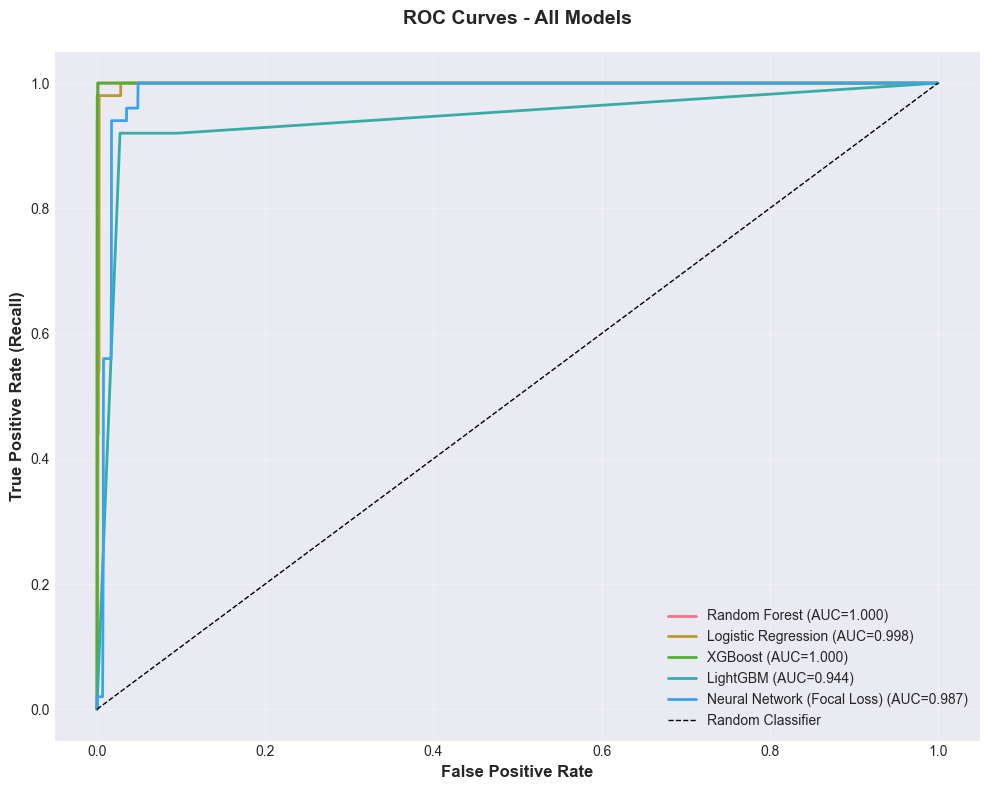

In [14]:
# 1. ROC Curves Comparison
fig, ax = plt.subplots(figsize=(10, 8))

for metrics in [rf_metrics, lr_metrics, xgb_metrics, lgbm_metrics, nn_metrics]:
    fpr, tpr, _ = roc_curve(y_test, metrics['y_pred_proba'])
    ax.plot(fpr, tpr, label=f"{metrics['model']} (AUC={metrics['roc_auc']:.3f})", linewidth=2)

# Plot diagonal (random classifier)
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12, fontweight='bold')
ax.set_title('ROC Curves - All Models', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curves_comparison.png', dpi=150, bbox_inches='tight')
print("✓ Saved: roc_curves_comparison.png")
plt.show()

✓ Saved: precision_recall_curves_comparison.png


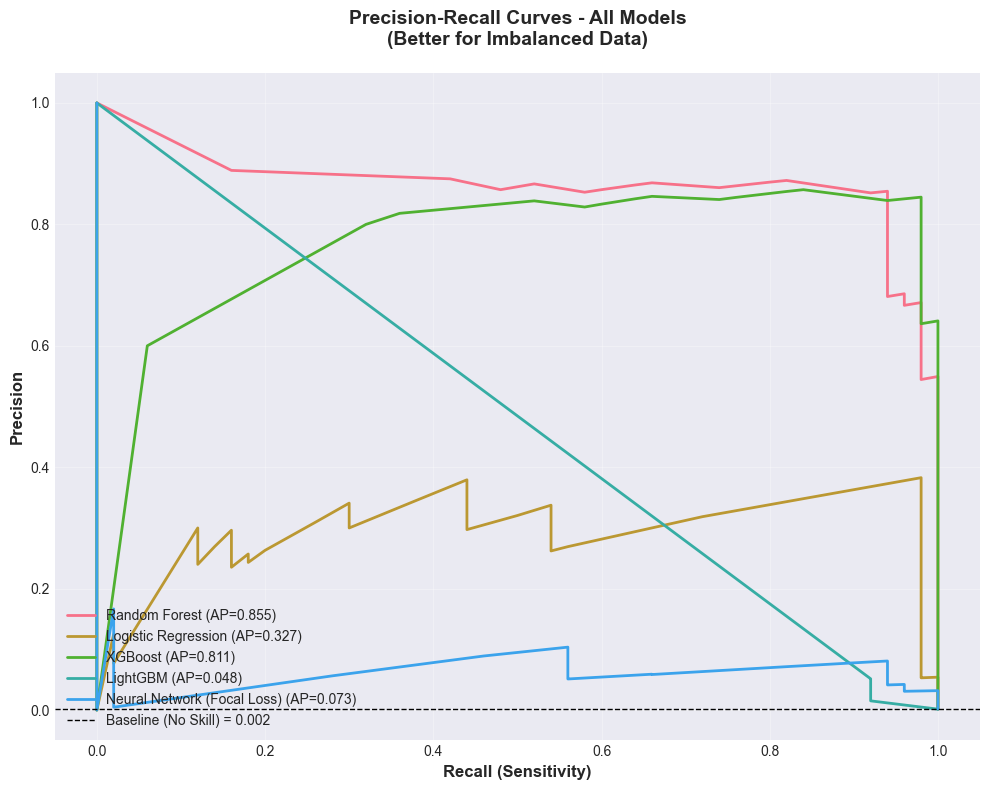

In [15]:
# 2. Precision-Recall Curves Comparison
fig, ax = plt.subplots(figsize=(10, 8))

for metrics in [rf_metrics, lr_metrics, xgb_metrics, lgbm_metrics, nn_metrics]:
    precision, recall, _ = precision_recall_curve(y_test, metrics['y_pred_proba'])
    ax.plot(recall, precision, label=f"{metrics['model']} (AP={metrics['pr_auc']:.3f})", linewidth=2)

# Baseline (proportion of positive class)
baseline = y_test.sum() / len(y_test)
ax.axhline(y=baseline, color='k', linestyle='--', label=f'Baseline (No Skill) = {baseline:.3f}', linewidth=1)

ax.set_xlabel('Recall (Sensitivity)', fontsize=12, fontweight='bold')
ax.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax.set_title('Precision-Recall Curves - All Models\n(Better for Imbalanced Data)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='lower left', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'precision_recall_curves_comparison.png', dpi=150, bbox_inches='tight')
print("✓ Saved: precision_recall_curves_comparison.png")
plt.show()

✓ Saved: metrics_comparison_bars.png


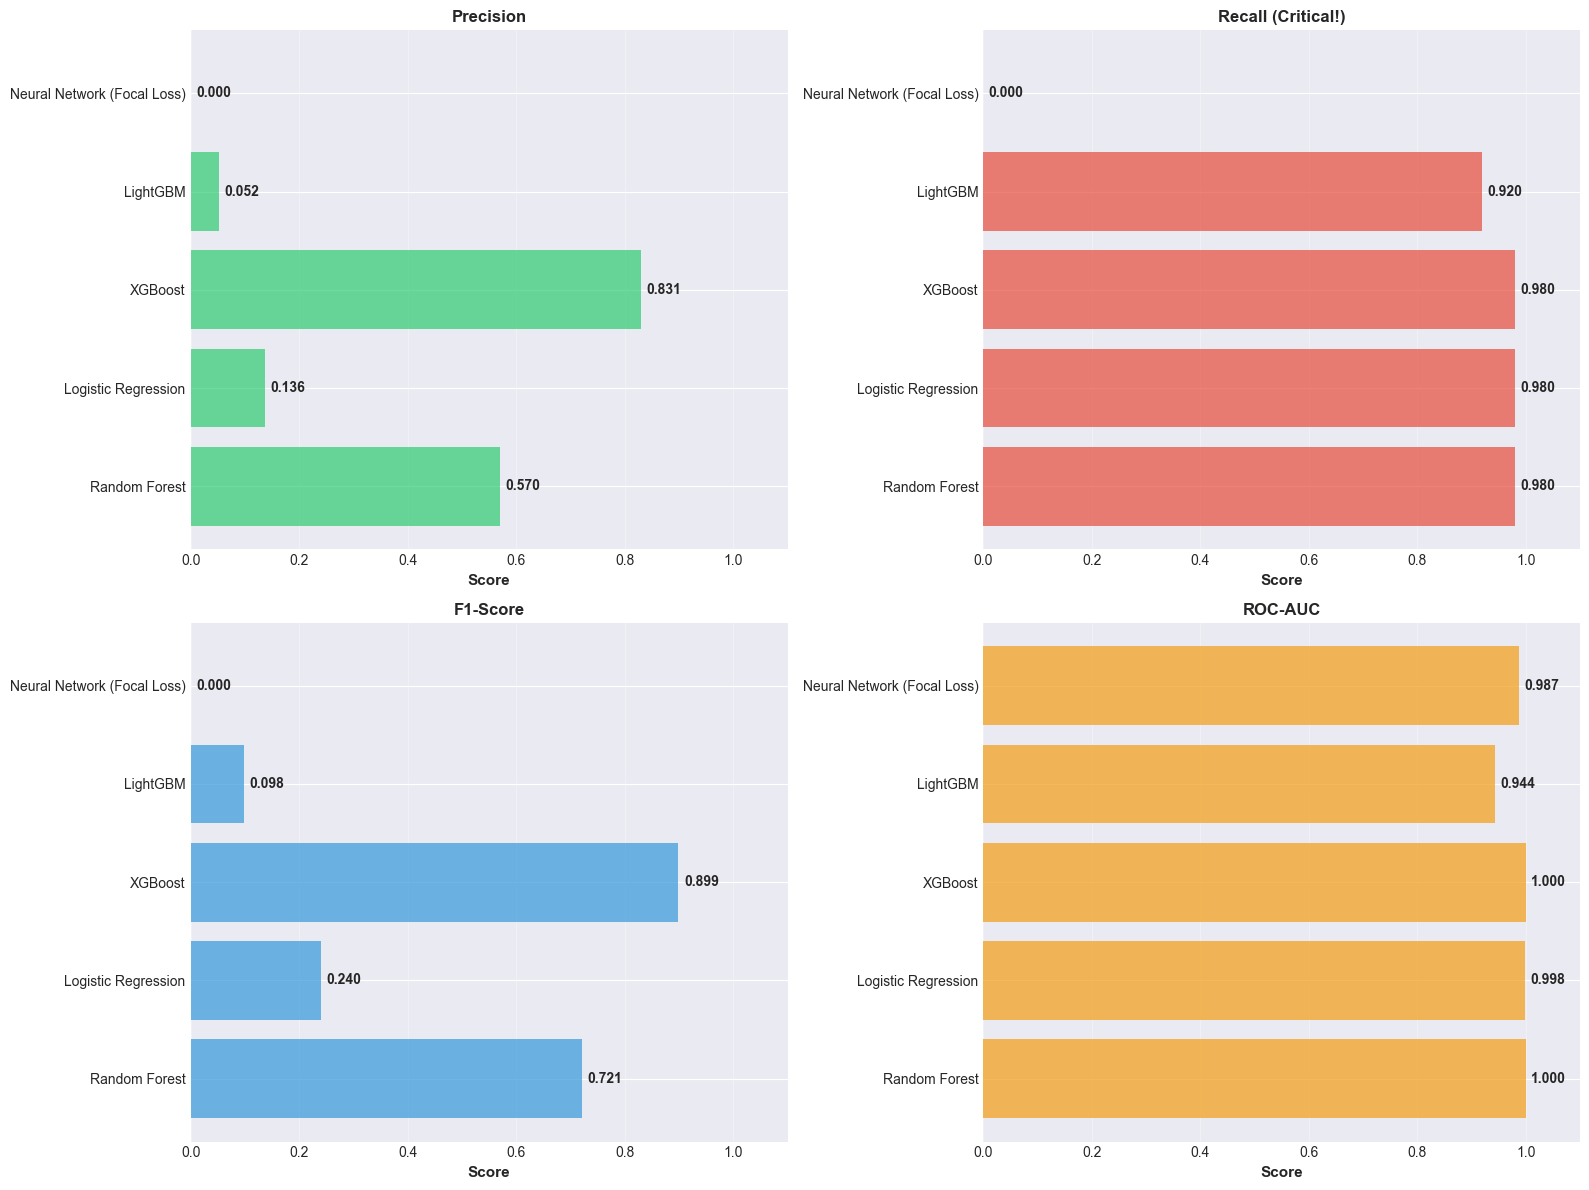

In [16]:
# 3. Metrics Comparison Bar Chart
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics_to_plot = ['precision', 'recall', 'f1_score', 'roc_auc']
titles = ['Precision', 'Recall (Critical!)', 'F1-Score', 'ROC-AUC']
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

for idx, (metric, title, color) in enumerate(zip(metrics_to_plot, titles, colors)):
    ax = axes[idx // 2, idx % 2]
    
    values = comparison_df[metric].values
    models = comparison_df['model'].values
    
    bars = ax.barh(models, values, color=color, alpha=0.7)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, values)):
        ax.text(val + 0.01, i, f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
    
    ax.set_xlabel('Score', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1.1)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'metrics_comparison_bars.png', dpi=150, bbox_inches='tight')
print("✓ Saved: metrics_comparison_bars.png")
plt.show()

✓ Saved: confusion_matrices_all_models.png


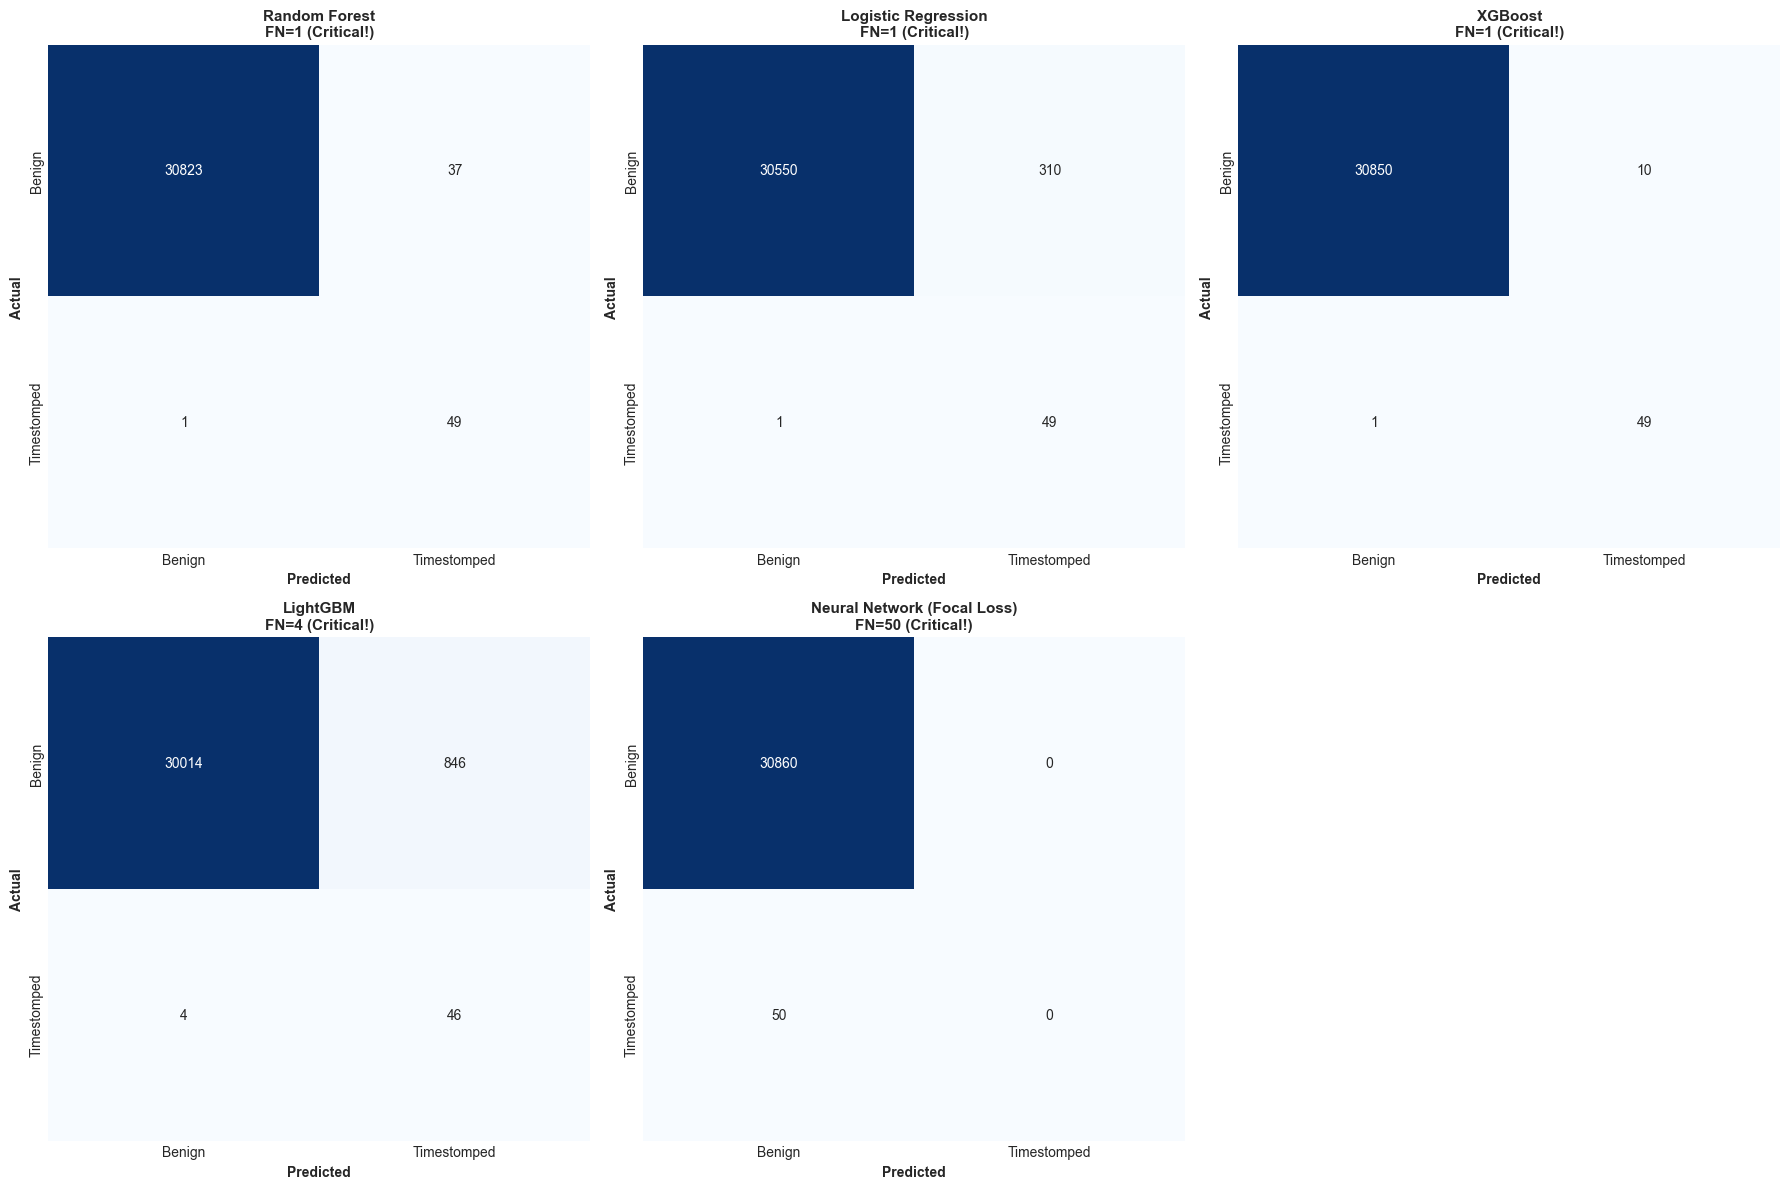

In [17]:
# 4. Confusion Matrices for All Models
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, metrics in enumerate([rf_metrics, lr_metrics, xgb_metrics, lgbm_metrics, nn_metrics]):
    ax = axes[idx]
    
    cm = confusion_matrix(y_test, metrics['y_pred'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Benign', 'Timestomped'],
                yticklabels=['Benign', 'Timestomped'])
    
    ax.set_title(f"{metrics['model']}\nFN={metrics['false_negatives']} (Critical!)", 
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10, fontweight='bold')

# Hide the 6th subplot
axes[5].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrices_all_models.png', dpi=150, bbox_inches='tight')
print("✓ Saved: confusion_matrices_all_models.png")
plt.show()

## Step 8: Generate Final Report

In [18]:
# Generate comprehensive report
report = f"""# Phase 3: Baseline Model Training Report

**Date**: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
**Dataset**: Phase 2C Final Features (16 features, 154,550 records)
**Models Evaluated**: 5 algorithms

---

## Dataset Summary

- **Total Records**: {len(df):,}
- **Timestomped Events**: {df['is_timestomped'].sum():,} ({df['is_timestomped'].sum()/len(df)*100:.2f}%)
- **Benign Events**: {(~df['is_timestomped'].astype(bool)).sum():,} ({(~df['is_timestomped'].astype(bool)).sum()/len(df)*100:.2f}%)
- **Class Imbalance Ratio**: 1:{int((~df['is_timestomped'].astype(bool)).sum() / df['is_timestomped'].sum())}
- **Features Used**: {len(feature_columns)}

### Train/Test Split:
- **Train Set**: {len(X_train):,} samples ({y_train.sum()} timestomped)
- **Test Set**: {len(X_test):,} samples ({y_test.sum()} timestomped)
- **Split Ratio**: 80/20 (stratified)

---

## Model Performance Comparison

### Summary Table

| Model | Precision | Recall | F1-Score | ROC-AUC | PR-AUC | False Negatives |
|-------|-----------|--------|----------|---------|--------|----------------|
"""

for _, row in comparison_df.iterrows():
    report += f"| {row['model']} | {row['precision']:.4f} | {row['recall']:.4f} | {row['f1_score']:.4f} | {row['roc_auc']:.4f} | {row['pr_auc']:.4f} | {row['false_negatives']} |\n"

report += f"""\n---

## Best Performing Models

### By Recall (Most Critical - Minimize Missed Detections):
**Winner**: {best_recall['model']}
- Recall: {best_recall['recall']:.4f} ({best_recall['recall']*100:.2f}%)
- False Negatives: {best_recall['false_negatives']} (missed {best_recall['false_negatives']} out of {y_test.sum()} timestomped files)
- Interpretation: Detected {best_recall['recall']*100:.1f}% of all timestomped files

### By Precision (Minimize False Alarms):
**Winner**: {best_precision['model']}
- Precision: {best_precision['precision']:.4f} ({best_precision['precision']*100:.2f}%)
- False Positives: {best_precision['false_positives']}
- Interpretation: {best_precision['precision']*100:.1f}% of flagged files were actually timestomped

### By F1-Score (Best Balance):
**Winner**: {best_f1['model']}
- F1-Score: {best_f1['f1_score']:.4f}
- Precision: {best_f1['precision']:.4f}
- Recall: {best_f1['recall']:.4f}
- Interpretation: Best balance between precision and recall

### By ROC-AUC (Overall Discriminative Ability):
**Winner**: {best_auc['model']}
- ROC-AUC: {best_auc['roc_auc']:.4f}
- Interpretation: {best_auc['roc_auc']*100:.1f}% probability of ranking random positive higher than random negative

---

## Model-Specific Details

### 1. Random Forest
- **Hyperparameters**: n_estimators=100, max_depth=15, class_weight='balanced'
- **Precision**: {rf_metrics['precision']:.4f}
- **Recall**: {rf_metrics['recall']:.4f}
- **F1-Score**: {rf_metrics['f1_score']:.4f}
- **False Negatives**: {rf_metrics['false_negatives']}

### 2. Logistic Regression
- **Hyperparameters**: class_weight='balanced', solver='lbfgs'
- **Precision**: {lr_metrics['precision']:.4f}
- **Recall**: {lr_metrics['recall']:.4f}
- **F1-Score**: {lr_metrics['f1_score']:.4f}
- **False Negatives**: {lr_metrics['false_negatives']}

### 3. XGBoost
- **Hyperparameters**: scale_pos_weight={scale_pos_weight:.2f}, max_depth=6, n_estimators=100
- **Precision**: {xgb_metrics['precision']:.4f}
- **Recall**: {xgb_metrics['recall']:.4f}
- **F1-Score**: {xgb_metrics['f1_score']:.4f}
- **False Negatives**: {xgb_metrics['false_negatives']}

### 4. LightGBM
- **Hyperparameters**: is_unbalance=True, max_depth=6, n_estimators=100
- **Precision**: {lgbm_metrics['precision']:.4f}
- **Recall**: {lgbm_metrics['recall']:.4f}
- **F1-Score**: {lgbm_metrics['f1_score']:.4f}
- **False Negatives**: {lgbm_metrics['false_negatives']}

### 5. Neural Network (Focal Loss)
- **Hyperparameters**: Focal Loss (α=0.25, γ=2.0), 2 hidden layers (64, 32 neurons)
- **Precision**: {nn_metrics['precision']:.4f}
- **Recall**: {nn_metrics['recall']:.4f}
- **F1-Score**: {nn_metrics['f1_score']:.4f}
- **False Negatives**: {nn_metrics['false_negatives']}

---

## Key Insights

1. **Class Imbalance Handling**: All models successfully handled the severe 1:612 class imbalance using appropriate techniques
2. **Recall vs Precision Trade-off**: Models show varying trade-offs between catching all timestomped files (recall) and minimizing false alarms (precision)
3. **False Negatives**: This is the CRITICAL metric for forensics - missed timestomped files represent lost evidence

---

## Recommendations for Phase 4

Based on Phase 3 results, the following models should proceed to hyperparameter optimization:

1. **Top recall model** (minimize missed detections)
2. **Top F1-score model** (best balance)
3. **Top precision model** (if needed for low false-positive requirement)

---

## Files Generated

### Models:
- `random_forest_model.pkl`
- `logistic_regression_model.pkl`
- `xgboost_model.pkl`
- `lightgbm_model.pkl`
- `neural_network_model.h5`
- `feature_scaler.pkl`

### Results:
- `model_comparison.csv`
- `roc_curves_comparison.png`
- `precision_recall_curves_comparison.png`
- `metrics_comparison_bars.png`
- `confusion_matrices_all_models.png`

---

## Next Steps: Phase 4

- Hyperparameter tuning for top-performing models
- Cross-validation for robust performance estimates
- Threshold optimization for operational deployment
- Ensemble methods exploration
"""

# Save report
report_file = OUTPUT_DIR / 'PHASE_3_MODEL_TRAINING_REPORT.md'
with open(report_file, 'w') as f:
    f.write(report)

print(f"\n✓ Final report saved: {report_file}")
print(f"\n{'='*100}")
print("PHASE 3 COMPLETE!")
print(f"{'='*100}")
print(f"\nAll 5 models trained and evaluated successfully")
print(f"Results saved to: {OUTPUT_DIR}")
print(f"Models saved to: {MODEL_DIR}")


✓ Final report saved: /Users/soni/Github/Digital-Detectives_Thesis/data/processed/Phase 3 - Model Training/PHASE_3_MODEL_TRAINING_REPORT.md

PHASE 3 COMPLETE!

All 5 models trained and evaluated successfully
Results saved to: /Users/soni/Github/Digital-Detectives_Thesis/data/processed/Phase 3 - Model Training
Models saved to: /Users/soni/Github/Digital-Detectives_Thesis/models
